## Australian Electricity Demand Forecasting

### Exploratory Data Analysis

In [84]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import kagglehub
import os

from PythonTsa.CointegrationTest import adfuller

path = kagglehub.dataset_download("joebeachcapital/nsw-australia-electricity-demand-2018-2023")
print("Path to dataset files:", path)
print(os.listdir(path))

Path to dataset files: /Users/fraserbytheway/.cache/kagglehub/datasets/joebeachcapital/nsw-australia-electricity-demand-2018-2023/versions/1
['PRICE_AND_DEMAND_202207_NSW1.csv', 'PRICE_AND_DEMAND_202206_NSW1.csv', 'PRICE_AND_DEMAND_201904_NSW1.csv', 'PRICE_AND_DEMAND_201905_NSW1.csv', 'PRICE_AND_DEMAND_202305_NSW1.csv', 'PRICE_AND_DEMAND_202304_NSW1.csv', 'PRICE_AND_DEMAND_201806_NSW1.csv', 'PRICE_AND_DEMAND_201807_NSW1.csv', 'PRICE_AND_DEMAND_202109_NSW1.csv', 'PRICE_AND_DEMAND_202108_NSW1.csv', 'PRICE_AND_DEMAND_202001_NSW1.csv', 'PRICE_AND_DEMAND_201912_NSW1.csv', 'PRICE_AND_DEMAND_202210_NSW1.csv', 'PRICE_AND_DEMAND_202211_NSW1.csv', 'PRICE_AND_DEMAND_202103_NSW1.csv', 'PRICE_AND_DEMAND_202102_NSW1.csv', 'PRICE_AND_DEMAND_201811_NSW1.csv', 'PRICE_AND_DEMAND_201810_NSW1.csv', 'PRICE_AND_DEMAND_202006_NSW1.csv', 'PRICE_AND_DEMAND_202007_NSW1.csv', 'PRICE_AND_DEMAND_202104_NSW1.csv', 'PRICE_AND_DEMAND_202105_NSW1.csv', 'PRICE_AND_DEMAND_202011_NSW1.csv', 'PRICE_AND_DEMAND_202010_NSW1.

In [85]:
df = pd.DataFrame()

for dataset in os.listdir(path):
    df = pd.concat([df, pd.read_csv(f"{path}/{dataset}")], ignore_index=True)

df['SETTLEMENTDATE'] = pd.to_datetime(df['SETTLEMENTDATE'])
df = df.sort_values('SETTLEMENTDATE', ascending=True)
df = df.drop('REGION', axis=1)
df = df.set_index('SETTLEMENTDATE')
df.head()

,TOTALDEMAND,RRP,PERIODTYPE
SETTLEMENTDATE,,,
2018-01-01 00:30:00,6912.25,91.86,TRADE
2018-01-01 01:00:00,6745.63,88.83,TRADE
2018-01-01 01:30:00,6466.06,73.62,TRADE
2018-01-01 02:00:00,6279.80,71.49,TRADE
2018-01-01 02:30:00,6177.31,69.27,TRADE


In [86]:
print("(rows, columns) =", df.shape)
df.describe()

(rows, columns) = (248592, 3)


,TOTALDEMAND,RRP
count,248592.000000,248592.000000
mean,7609.351612,128.619204
std,1270.924160,289.366592
min,3957.320000,-1000.000000
25%,6682.177500,59.950000
50%,7470.850000,89.010000
75%,8324.510000,144.410000
max,13700.900000,15500.000000


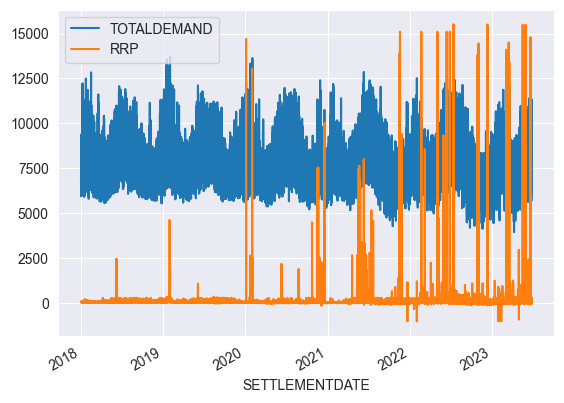

In [87]:
df.plot()
df.to_parquet('fullElectricityDataset')

#### Investigating Total Demand

In [88]:
df = df['TOTALDEMAND']
df

SETTLEMENTDATE
2018-01-01 00:30:00    6912.25
2018-01-01 01:00:00    6745.63
2018-01-01 01:30:00    6466.06
2018-01-01 02:00:00    6279.80
2018-01-01 02:30:00    6177.31
                        ...   
2023-06-27 23:40:00    8536.43
2023-06-27 23:45:00    8527.02
2023-06-27 23:50:00    8489.29
2023-06-27 23:55:00    8358.07
2023-06-28 00:00:00    8394.93
Name: TOTALDEMAND, Length: 248592, dtype: float64

Text(0.5, 1.0, 'Histogram of Electricity Demand')

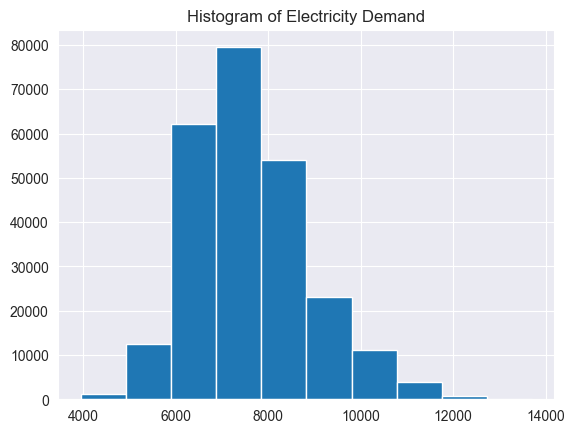

In [89]:
plt.hist(df)
plt.title("Histogram of Electricity Demand")

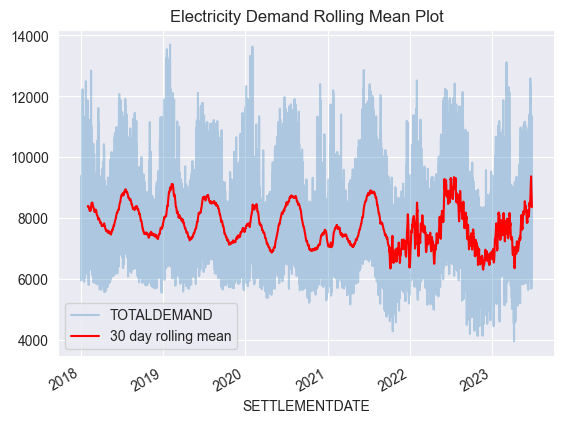

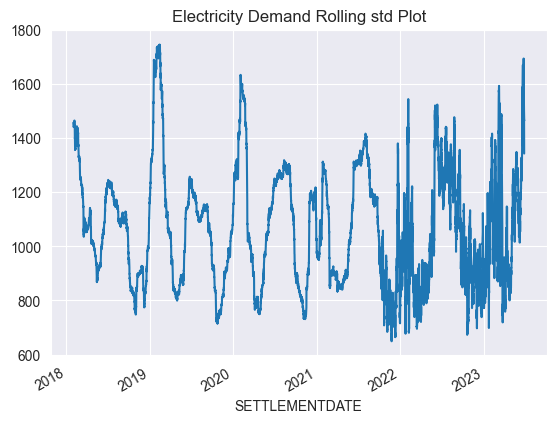

In [90]:
df.plot(alpha=0.3)
df_rolling = df.rolling(1440).mean().dropna()
df_std = df.rolling(1440).std().dropna()
df_rolling.plot(color='red', label='30 day rolling mean')
plt.title('Electricity Demand Rolling Mean Plot')
plt.legend()
plt.show()

df_std.plot(title='Electricity Demand Rolling std Plot')
plt.show()

* standard deviation highly heteroskedastic
* rolling mean shows clear seasonality, overall effect seems to be multiplicative

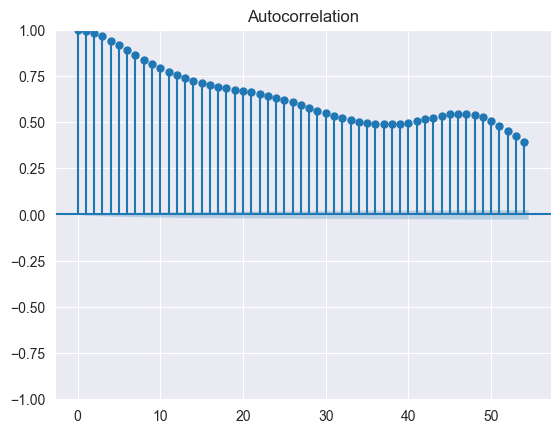

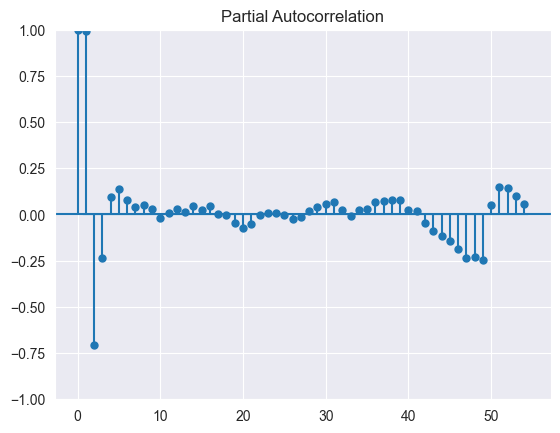

In [91]:
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

plot_acf(df)
plt.show()

plot_pacf(df)
plt.show()

Demand data is very clearly non stationary, as expected. Investigating possible seasonal trends bollow

**Monthly Seasonal Analysis**

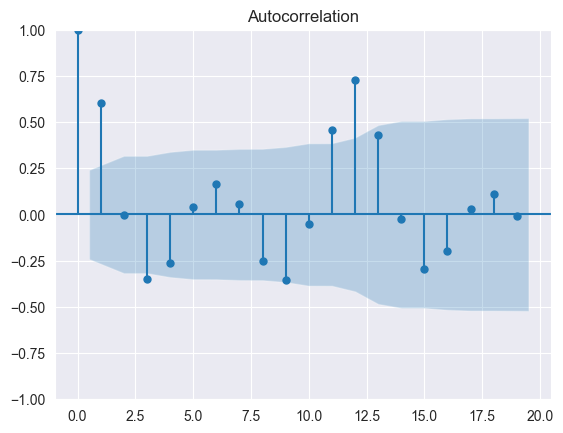

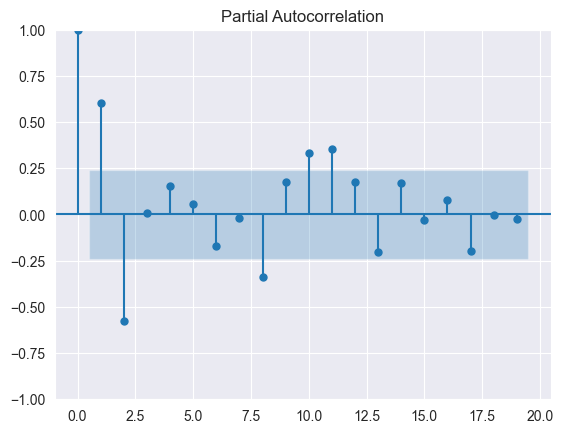

In [113]:
df_mgroup = df.resample('ME').mean()

plot_acf(df_mgroup)
plt.show()
plot_pacf(df_mgroup)
plt.show()

large correlation spike around the ~1 year mark, implying a yearly seasonal trend. Spikes at 1/2 lag imply seasonal trends

**Seasonal Decomposition** - Investigate seasonal trends within the data

Using multiplicative model, as overall demand grows over time. Daily aggregation to get higher level trends in plots

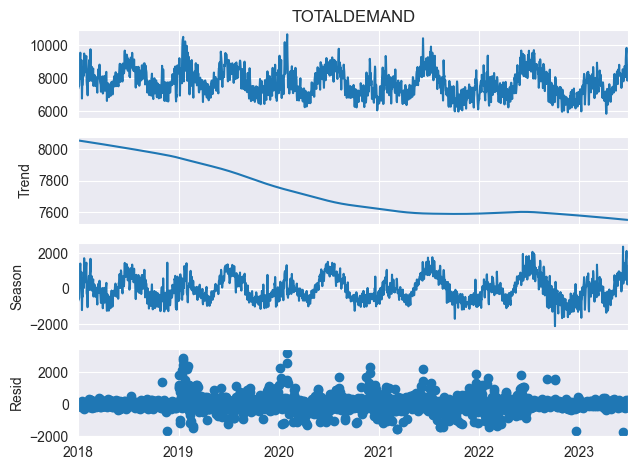

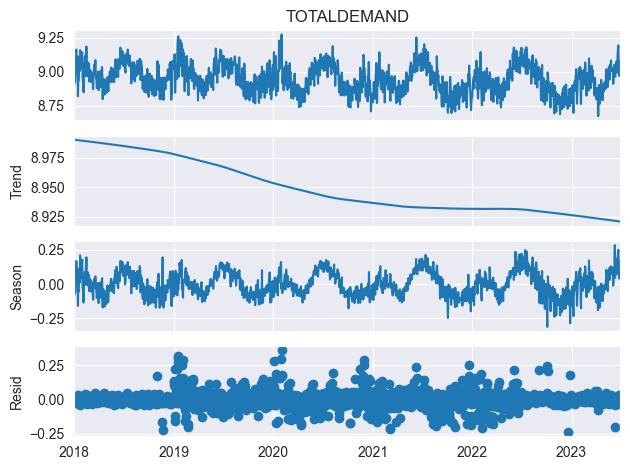

In [141]:
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.seasonal import MSTL

df_daily = df.resample('D').mean()

# additive model
stl_annual = STL(df_daily, period=365, robust=True).fit()
stl_annual.plot()
plt.show()

# multiplicative model
df_daily_log = np.log(df_daily)
stl = STL(df_daily_log, period=365, robust=True).fit()
stl.plot()
plt.show()


Clear pattern in the seasonal decomposition, though overall for both decompositions, the seasonal amplitude still seems to grow over time, implying that both the additive and multiplicative model may not be sufficient.

Trend is actually decreasing over time. This is likely a result of Rooftop solar adaptation, reducing grid demand. Structural break seemed to occur around 2019, then again in around 2021.

STL decomposition diagnostic check

In [148]:
print(f'Trend variance:    {stl.trend.var():.4f}')
print(f'Seasonal variance: {stl.seasonal.var():.4f}')
print(f'Residual variance: {stl.resid.var():.4f}')

Fs = max(0, 1 - stl.resid.var() /
         (stl.seasonal + stl.resid).var())
print(f'Seasonal strength: {Fs:.4f}')

Trend variance:    0.0005
Seasonal variance: 0.0076
Residual variance: 0.0031
Seasonal strength: 0.6795


seasonal strength is strong.

**weekly analysis** Would expect energy consumption to behave differently on weekdays and weekends. Testing if there is any pattern here

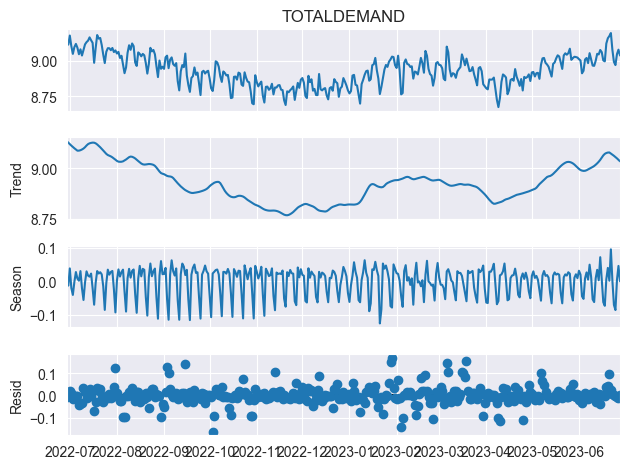

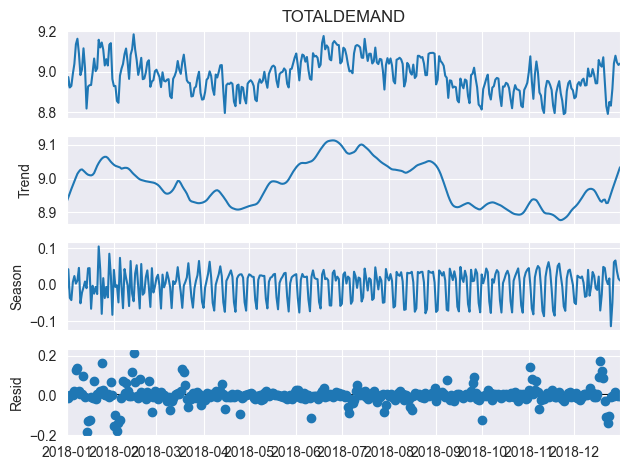

In [157]:
# using subset of data so plots aren't too noisy. Two seperate years for comparison
df_ss1 = np.log(df_day[-365:])
stl_weekly1 = STL(df_ss1, period=7, robust=True).fit()

stl_weekly1.plot()
plt.show()

df_ss2 = np.log(df_day[:365])
stl_weekly2 = STL(df_ss2, period=7, robust=True).fit()

stl_weekly2.plot()
plt.show()

In [158]:
Fs = max(0, 1 - stl_weekly1.resid.var() /
         (stl_weekly1.seasonal + stl_weekly1.resid).var())
print(f'Seasonal strength: {Fs:.4f}')

Seasonal strength: 0.4721


A weekly seasonal trend also seems to exist, though is weeker (only explains about half the non trend variation)

### Time Series SARIMA Model

Manual Construction

In [176]:
from PythonTsa.CointegrationTest import adfuller

# multiplicative model
df_log = np.log(df)

# remove weekly seasonal trends
df_log_wdiff = df_log.diff(2*24*7).dropna()

result = adfuller(df_log_wdiff)
print(f"Stationarity Test: p-value after weekly diff:", result[1])

# remove yearly seasonal trends
df_log_ddiff = df_log_wdiff.diff(2*24*365).dropna()

result = adfuller(df_log_ddiff)
print(f"Stationarity Test: p-value after weekly + annual diff:", result[1])

Stationarity Test: p-value after weekly diff: 0.0
Stationarity Test: p-value after weekly + annual diff: 0.0


Stationarity test statistically significant for just weekly diff. Will use the weekly model.

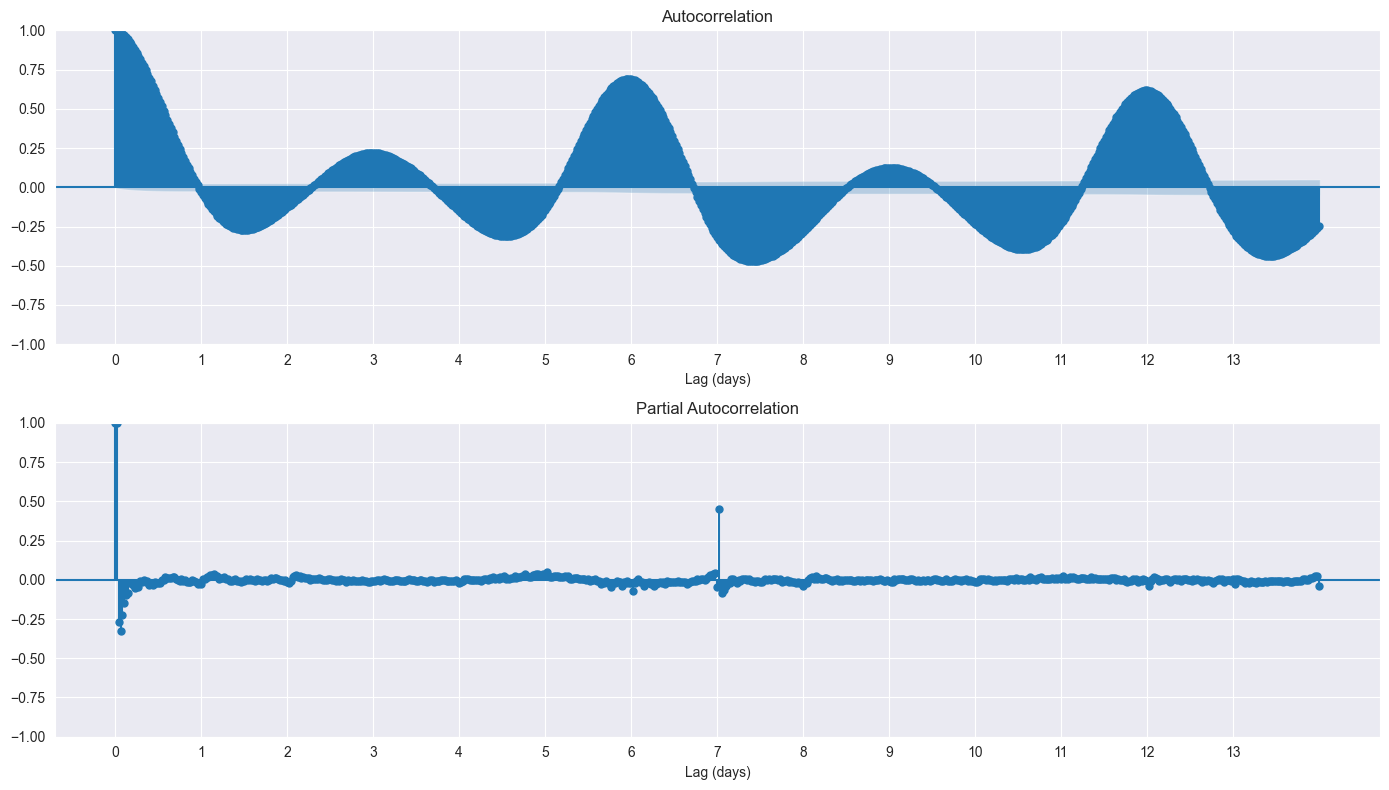

In [180]:
lags = 48 * 14

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(df_log_wdiff, lags=lags, ax=axes[0])
plot_pacf(df_log_wdiff, lags=lags, ax=axes[1])

for ax in axes:
    ax.set_xticks(range(0, lags, 48))
    ax.set_xticklabels(range(0, lags // 48))
    ax.set_xlabel('Lag (days)')

plt.tight_layout()
plt.show()